# Final Project – Chicago Building Permits: Investment Opportunity Assessment
**Group 50:** Audrey Zhang, Jeena Lee, Vincent Wang

> *A data-driven guide for real estate developers and investment firms evaluating Chicago neighborhood opportunities.*

In [1]:
import requests
import pandas as pd
import time

# 1. Data Collection via API


## Target Audience
This analysis is designed for **real estate developers and investment firms** seeking data-driven insights to identify profitable construction and development opportunities in Chicago neighborhoods.

## Analysis Motivation
The Chicago construction market represents significant investment potential. Thus, by identifying the right neighborhoods through looking at permit activity and underlying socioeconomic factors, we can see factors that drive property appreciation.

We plan to combine 2024- Present day building permit data with neighborhood demographics so that we can:

- **Identify high-growth neighborhoods** with concentrated development activity
- **Evaluate socioeconomic factors** (income, poverty) that affect investment returns
- **Understand project cost distributions** across different community areas
- **Assess market composition** (residential renovations vs. commercial construction)
- **Detect seasonal patterns** for optimal project timing
- **Create composite investment scores** integrating development and demographic data

## Key Questions
1. Which Chicago community areas are experiencing the most construction investment?
2. How do neighborhood income levels correlate with development activity?
3. What is the typical cost structure for different project types?
4. Do wealthier areas attract more investment, or are there gentrification opportunities in lower-income areas?
5. Which neighborhoods offer the best risk-adjusted investment opportunities?

## Datasets
- **Primary**: Chicago Building Permits (Socrata API) - Permit activity, costs, project types
- **Secondary**: Chicago Socioeconomic Indicators (Socrata API) - Income, poverty, unemployment by community area
- **Date Range**: January 2024 - Present

In [2]:
# API Setup: Chicago Building Permits
# We're using the Socrata Open Data API (SODA)
# Dataset: Building Permits from City of Chicago Data Portal
base_url = "https://data.cityofchicago.org/resource/ydr8-5enu.json"

In [3]:
# Pagination Setup
# Socrata APIs limit results per request, so we need to paginate
# We'll use offset to get all available records
limit = 1000  
offset = 0    
all_data = [] 
more_data = True

In [4]:
# While Loop to Download ALL Data (Paginated)
while more_data:
    params = {
        "$limit": limit,
        "$offset": offset,
        "$order": "issue_date DESC", 
        "$where": "issue_date > '2024-01-01T00:00:00'", 
        "$select": "issue_date, reported_cost, total_fee, community_area, work_description, permit_type" 
    }
    
    response = requests.get(base_url, params=params)
    
    if response.status_code == 200:
        data = response.json()
        
        # If we get an empty list, we've reached the end
        if not data:
            more_data = False
        else:
            all_data.extend(data)
            offset += limit
            print(f"Downloaded {len(data)} rows... Total: {len(all_data)}")
    else:
        print(f"{response.status_code}")
        print(response.text)
        break

print(f"API download complete")

Downloaded 1000 rows... Total: 1000
Downloaded 1000 rows... Total: 2000
Downloaded 1000 rows... Total: 3000
Downloaded 1000 rows... Total: 4000
Downloaded 1000 rows... Total: 5000
Downloaded 1000 rows... Total: 6000
Downloaded 1000 rows... Total: 7000
Downloaded 1000 rows... Total: 8000
Downloaded 1000 rows... Total: 9000
Downloaded 1000 rows... Total: 10000
Downloaded 1000 rows... Total: 11000
Downloaded 1000 rows... Total: 12000
Downloaded 1000 rows... Total: 13000
Downloaded 1000 rows... Total: 14000
Downloaded 1000 rows... Total: 15000
Downloaded 1000 rows... Total: 16000
Downloaded 1000 rows... Total: 17000
Downloaded 1000 rows... Total: 18000
Downloaded 1000 rows... Total: 19000
Downloaded 1000 rows... Total: 20000
Downloaded 1000 rows... Total: 21000
Downloaded 1000 rows... Total: 22000
Downloaded 1000 rows... Total: 23000
Downloaded 1000 rows... Total: 24000
Downloaded 1000 rows... Total: 25000
Downloaded 1000 rows... Total: 26000
Downloaded 1000 rows... Total: 27000
Downloaded

In [5]:
# Convert to DataFrame
permits_df = pd.DataFrame(all_data)
permits_df.shape

(69929, 6)

In [6]:
 permits_df.columns.tolist()

['issue_date',
 'total_fee',
 'community_area',
 'work_description',
 'permit_type',
 'reported_cost']

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 2. Data Quality Checks

Before analyzing the data, we need to verify data integrity and identify any issues that could affect our investment insights.

In [8]:
# Convert data types
permits_df['issue_date'] = pd.to_datetime(permits_df['issue_date'])
permits_df['reported_cost'] = pd.to_numeric(permits_df['reported_cost'], errors='coerce')
permits_df['total_fee'] = pd.to_numeric(permits_df['total_fee'], errors='coerce')

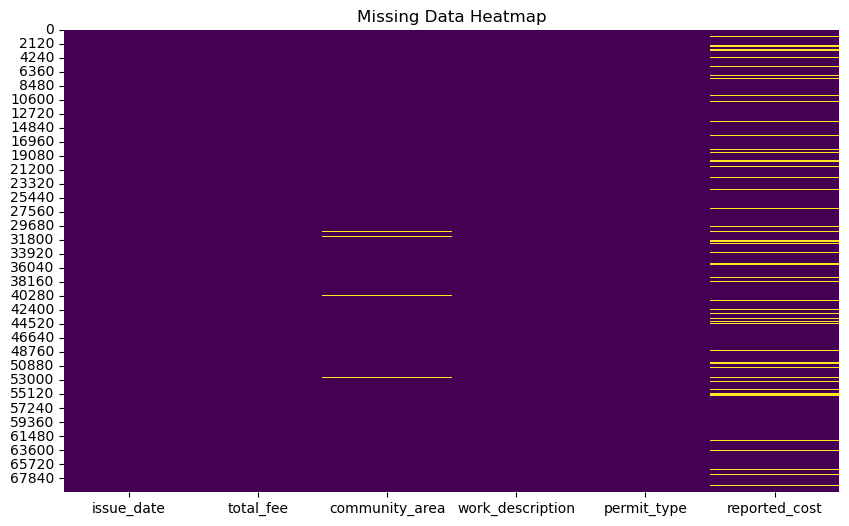

In [9]:
# Check for missing values - visualize with heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(permits_df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

### Data Cleaning Strategy

We'll remove records with missing critical fields (community area, reported cost) since these are essential for our investment analysis. Missing fee data will be handled separately as it's less critical.

In [10]:
# Drop rows with missing critical fields
df_clean = permits_df.dropna(subset=['community_area', 'reported_cost'])

print(f"Original: {permits_df.shape[0]:,} rows | Cleaned: {df_clean.shape[0]:,} rows")

Original: 69,929 rows | Cleaned: 61,366 rows


In [11]:
# Missing data summary — how much data is missing for each column?
missing_summary = pd.DataFrame({
    'Column': permits_df.columns,
    'Missing Count': permits_df.isnull().sum().values,
    'Missing %': (permits_df.isnull().sum() / len(permits_df) * 100).round(2).values
}).sort_values('Missing %', ascending=False)

# Show only columns that have missing data
missing_summary[missing_summary['Missing Count'] > 0].reset_index(drop=True)


,Column,Missing Count,Missing %
0,reported_cost,8087,11.56
1,community_area,653,0.93
2,work_description,5,0.01


In [12]:
# Check for negative costs (data quality issue)
negative_costs = df_clean[df_clean['reported_cost'] < 0]
print(f"Rows with negative costs: {len(negative_costs)}")

Rows with negative costs: 0


In [13]:
# Check for Duplicates
duplicate_count = df_clean.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

# Check if any permits have the same date, cost, and community area (suspicious)
suspicious_dupes = df_clean.duplicated(subset=['issue_date', 'reported_cost', 'community_area'], keep=False)
print(f"Potentially suspicious duplicate permits: {suspicious_dupes.sum()}")

Duplicate rows: 1804
Potentially suspicious duplicate permits: 8154


In [14]:
# 6. Verify Data Types and Summary Statistics 
df_clean.dtypes

issue_date          datetime64[us]
total_fee                  float64
community_area                 str
work_description               str
permit_type                    str
reported_cost              float64
dtype: object

In [15]:

df_clean[['reported_cost', 'total_fee']].describe()

,reported_cost,total_fee
count,6.136600e+04,6.136600e+04
mean,3.110852e+05,1.367163e+03
std,9.137341e+06,1.132874e+04
min,0.000000e+00,0.000000e+00
25%,3.500000e+03,1.750000e+02
50%,1.428000e+04,3.500000e+02
75%,5.000000e+04,6.750000e+02
max,1.934275e+09,1.379255e+06


In [16]:

# Check for unrealistic values
print("\n=== Value Range Checks ===")
print(f"Max reported cost: ${df_clean['reported_cost'].max():,.2f}")
print(f"Min reported cost: ${df_clean['reported_cost'].min():,.2f}")
print(f"Zero-cost permits: {(df_clean['reported_cost'] == 0).sum()}")
print(f"Very high cost permits (>$10M): {(df_clean['reported_cost'] > 10_000_000).sum()}")


=== Value Range Checks ===
Max reported cost: $1,934,275,000.00
Min reported cost: $0.00
Zero-cost permits: 1223
Very high cost permits (>$10M): 209


In [17]:
# Explore Unique Values in Categorical Variables

print(f"Unique Community Areas: {df_clean['community_area'].nunique()}")
print(f"Community Area Codes: {sorted(df_clean['community_area'].unique())}\n")

Unique Community Areas: 78
Community Area Codes: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '8', '9']



In [18]:
print(f"Unique Permit Types: {df_clean['permit_type'].nunique()}")
print("Permit Type Distribution:")
df_clean['permit_type'].value_counts().head(10)

Unique Permit Types: 8
Permit Type Distribution:


permit_type
PERMIT – EXPRESS PERMIT PROGRAM    36038
PERMIT - RENOVATION/ALTERATION     12554
PERMIT - SIGNS                      5132
PERMIT - NEW CONSTRUCTION           2874
PERMIT - ELEVATOR EQUIPMENT         2446
PERMIT - WRECKING/DEMOLITION        1437
PERMIT - REINSTATE REVOKED PMT       845
PERMIT - EASY PERMIT PROCESS          40
Name: count, dtype: int64

In [19]:
# Work descriptions are likely too diverse, so just show count
print(f"Unique Work Descriptions: {df_clean['work_description'].nunique()}")
print("Top 10 Work Descriptions:")
print(df_clean['work_description'].value_counts().head(10))

Unique Work Descriptions: 50492
Top 10 Work Descriptions:
work_description
REPAIR SERVICE                                                                                                                                                                                                       354
FULL REBUILD (SAME AS EXISTING) FOR WOOD PORCH (OPEN) (QUANTITY: 1, LOCATION: REAR OF BUILDING).                                                                                                                     170
MONTHLY MAINTENANCE                                                                                                                                                                                                  150
NEW DETACHED WOOD FRAME GARAGE. DIMENSIONS AND SETBACKS PER APPLICATION. BUILDING OUTSIDE DIMENSIONS: 22'-0' ' X20'-0' '. HIP ROOF HEIGHT TO PEAK: 13'-0' '.                                                         106
REMOVE AND REPLACE EXISTING REAR OPEN WOOD PORCH AND STAI

In [20]:
import numpy as np

# 3. Integrating Outside Data: Chicago Socioeconomic Indicators

For real estate investors, understanding neighborhood demographics and economic health is critical. Areas with higher incomes, better education, and lower poverty rates typically offer stronger investment potential and property appreciation.

In [21]:
# Download Chicago socioeconomic indicators by community area
# This dataset includes income, poverty, education, unemployment, and housing data
socio_url = "https://data.cityofchicago.org/resource/kn9c-c2s2.json"

socio_response = requests.get(socio_url)

if socio_response.status_code == 200:
    socio_data = socio_response.json()
    df_socio = pd.DataFrame(socio_data)
    print(f"Downloaded socioeconomic data for {len(df_socio)} community areas\n")
    df_socio.head()
else:
    print(f"Error: {socio_response.status_code}")

Downloaded socioeconomic data for 78 community areas



In [22]:
# Clean and prepare socioeconomic data for merging
print(df_socio.columns.tolist())
print("\n")


['ca', 'community_area_name', 'percent_of_housing_crowded', 'percent_households_below_poverty', 'percent_aged_16_unemployed', 'percent_aged_25_without_high_school_diploma', 'percent_aged_under_18_or_over_64', 'per_capita_income_', 'hardship_index']




In [23]:
# Clean and prepare socioeconomic data for merging
# Convert to proper types using the actual column names from the API
df_socio['community_area'] = df_socio['ca'].astype(str)
df_socio['per_capita_income'] = pd.to_numeric(df_socio['per_capita_income_'], errors='coerce')
df_socio['percent_households_below_poverty'] = pd.to_numeric(df_socio['percent_households_below_poverty'], errors='coerce')
df_socio['percent_unemployed'] = pd.to_numeric(df_socio['percent_aged_16_unemployed'], errors='coerce')

# Select key indicators for merging
socio_subset = df_socio[['community_area', 'community_area_name', 'per_capita_income', 
                          'percent_households_below_poverty', 'percent_unemployed']].copy()

socio_subset.head(10)

,community_area,community_area_name,per_capita_income,percent_households_below_poverty,percent_unemployed
0,1,Rogers Park,23939,23.6,8.7
1,2,West Ridge,23040,17.2,8.8
2,3,Uptown,35787,24.0,8.9
3,4,Lincoln Square,37524,10.9,8.2
4,5,North Center,57123,7.5,5.2
5,6,Lake View,60058,11.4,4.7
6,7,Lincoln Park,71551,12.3,5.1
7,8,Near North Side,88669,12.9,7.0
8,9,Edison Park,40959,3.3,6.5
9,10,Norwood Park,32875,5.4,9.0


In [24]:
# Merge socioeconomic data with building permits
df_clean = df_clean.merge(socio_subset, on='community_area', how='left')

# Fill missing values with median (for areas without socioeconomic data)
df_clean['per_capita_income'].fillna(df_clean['per_capita_income'].median(), inplace=True)
df_clean['percent_households_below_poverty'].fillna(df_clean['percent_households_below_poverty'].median(), inplace=True)
df_clean['percent_unemployed'].fillna(df_clean['percent_unemployed'].median(), inplace=True)

print(f"Merged dataset shape: {df_clean.shape}")
print(f"\nSample of merged data:")
df_clean[['community_area', 'community_area_name', 'reported_cost', 'per_capita_income', 'percent_households_below_poverty']].head()

Merged dataset shape: (61366, 10)

Sample of merged data:


/tmp/ipykernel_3299/3587226496.py:5: ChainedAssignmentError: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean['per_capita_income'].fillna(df_clean['per_capita_income'].median(), inplace=True)
/tmp/ipykernel_3299/3587226496.py:6: ChainedAssignmentError: A value is trying to be set on a copy of a DataFrame or Series through chained assignment usi

,community_area,community_area_name,reported_cost,per_capita_income,percent_households_below_poverty
0,3,Uptown,50000.0,35787.0,24.0
1,65,West Lawn,6000.0,16907.0,14.9
2,49,Roseland,10500.0,17949.0,19.8
3,25,Austin,85000.0,15957.0,28.6
4,32,Loop,364987.0,65526.0,14.7


# 4. Feature Engineering

In [25]:
# Feature 1: Processing Time (Days) - Optional if we had application_date
# Don't have so extracting the MONTH to see if construction is seasonal
df_clean['issue_month'] = df_clean['issue_date'].dt.month_name()

In [26]:
# Feature 2: Cost Bracket (Categorical)
# We categorize the 'reported_cost' to see project size
def categorize_cost(cost):
    if cost < 10000:
        return 'Minor Reno'
    elif cost < 100000:
        return 'Major Reno'
    else:
        return 'New Construction/Commercial'

df_clean['project_type'] = df_clean['reported_cost'].apply(categorize_cost)

In [27]:
# Identify outliers using IQR method
Q1 = df_clean['reported_cost'].quantile(0.25)
Q3 = df_clean['reported_cost'].quantile(0.75)
IQR = Q3 - Q1

outliers = df_clean[(df_clean['reported_cost'] < (Q1 - 1.5 * IQR)) | (df_clean['reported_cost'] > (Q3 + 1.5 * IQR))]
print(f"Found {len(outliers)} cost outliers (keeping them - likely large commercial projects)")

Found 10026 cost outliers (keeping them - likely large commercial projects)


In [28]:
# Create fee-to-cost ratio (high ratios may indicate complex zoning)
df_clean['fee_ratio'] = df_clean['total_fee'] / df_clean['reported_cost']
df_clean['fee_ratio'] = df_clean['fee_ratio'].replace([np.inf, -np.inf], 0)

df_clean[['issue_month', 'project_type', 'fee_ratio']].head()

,issue_month,project_type,fee_ratio
0,March,Major Reno,0.013540
1,March,Minor Reno,0.029167
2,March,Major Reno,0.007143
3,March,Major Reno,0.009152
4,March,New Construction/Commercial,0.009348


In [29]:
# Create dummy variables for project type (One-Hot Encoding)
project_type_dummies = pd.get_dummies(df_clean['project_type'], prefix='is')
df_clean = pd.concat([df_clean, project_type_dummies], axis=1)

project_type_dummies.columns.tolist()

['is_Major Reno', 'is_Minor Reno', 'is_New Construction/Commercial']

In [30]:
# Normalize key numeric features (Min-Max Scaling to 0-1)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_clean['cost_normalized'] = scaler.fit_transform(df_clean[['reported_cost']])
df_clean['income_normalized'] = scaler.fit_transform(df_clean[['per_capita_income']])

# Also create inverse poverty score (lower poverty = higher score)
df_clean['poverty_inverse'] = 100 - df_clean['percent_households_below_poverty']
df_clean['poverty_normalized'] = scaler.fit_transform(df_clean[['poverty_inverse']])

df_clean[['cost_normalized', 'income_normalized', 'poverty_normalized']].describe()

,cost_normalized,income_normalized,poverty_normalized
count,61366.000000,61359.000000,61359.000000
mean,0.000161,0.340063,0.696133
std,0.004724,0.283630,0.173952
min,0.000000,0.000000,0.000000
25%,0.000002,0.108192,0.575188
50%,0.000007,0.225580,0.746241
75%,0.000026,0.453447,0.819549
max,1.000000,1.000000,1.000000


In [31]:
# Create Investment Opportunity Score
# Formula: 40% development activity + 30% income + 30% low poverty
# This weights current investment, affluence, and economic stability
df_clean['investment_score'] = (
    df_clean['cost_normalized'] * 0.4 + 
    df_clean['income_normalized'] * 0.3 + 
    df_clean['poverty_normalized'] * 0.3
)

In [32]:
df_clean['investment_score'].describe()

count    61359.000000
mean         0.310923
std          0.122672
min          0.000000
25%          0.203737
50%          0.312277
75%          0.406635
max          0.945865
Name: investment_score, dtype: float64

- Investment Score Formula:
- 40% Construction Activity (normalized permit costs)
- 30% Affluence (normalized per capita income)
- 30% Economic Stability (inverse of poverty rate)
- Note: Weights (40/30/30) are initial estimates and would be refined based investor preferences and historical ROI data in production use.

In [33]:
# Map calendar months to seasons using pandas .map() — useful for seasonal investment analysis
season_map = {
    1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Fall', 10: 'Fall',
    11: 'Fall',  12: 'Winter'
}
df_clean['season'] = df_clean['issue_date'].dt.month.map(season_map)

# Seasonal investment summary — aggregate investment by season for actionable timing insight
season_summary = (df_clean.groupby('season')['reported_cost']
                  .agg(Permit_Count='count', Total_Investment='sum', Median_Cost='median')
                  .reindex(['Spring', 'Summer', 'Fall', 'Winter'])
                  .assign(Avg_Investment_Per_Permit=lambda d: d['Total_Investment'] / d['Permit_Count'])
                  .round(0))
season_summary


,Permit_Count,Total_Investment,Median_Cost,Avg_Investment_Per_Permit
season,,,,
Spring,15719,3.968919e+09,12700.0,252492.0
Summer,16205,6.161304e+09,13338.0,380210.0
Fall,14434,4.408562e+09,15000.0,305429.0
Winter,15008,4.551268e+09,14030.0,303256.0


# 5. Exploratory Data Analysis

Now we'll analyze patterns and relationships in the data to identify investment opportunities.

## Analysis Framework

Our exploratory analysis addresses five critical investment questions through multi-dimensional data analysis:

1. **Where is capital concentrating?** - Geographic and neighborhood-level investment patterns
2. **What strategies are viable?** - Cost structures, project types, and capital requirements across markets
3. **Who are the successful investors targeting?** - Demographic correlations with development activity
4. **When should projects be initiated?** - Seasonal patterns and optimal timing windows
5. **Which opportunities offer the best risk-adjusted returns?** - Composite scoring integrating development activity, costs, and socioeconomic factors

This framework combines neighborhood-level granularity with regional macro-trends to provide actionable insights for investors with varying capital availability and risk tolerance.

### Top Investment Areas

Which neighborhoods attract the most construction capital?

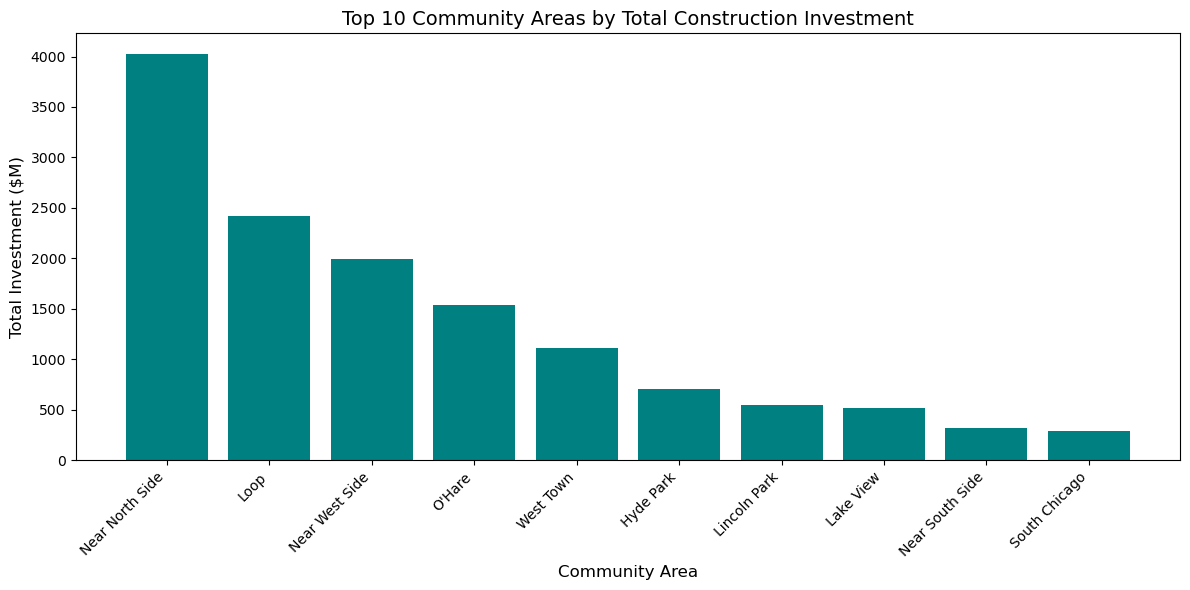

In [34]:
investment_by_area = df_clean.groupby('community_area').agg({
    'reported_cost': 'sum',
    'community_area_name': 'first'
}).sort_values('reported_cost', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(range(len(investment_by_area)), investment_by_area['reported_cost']/1e6, color='teal')
labels = investment_by_area['community_area_name'].fillna(pd.Series(investment_by_area.index, index=investment_by_area.index))
plt.xticks(range(len(investment_by_area)), labels.str[:15], rotation=45, ha='right')
plt.title("Top 10 Community Areas by Total Construction Investment", fontsize=14)
plt.ylabel("Total Investment ($M)", fontsize=12)
plt.xlabel("Community Area", fontsize=12)
plt.tight_layout()
plt.show()

### Project Cost Distribution by Permit Type

Understanding the typical cost range for each permit category helps developers set realistic budgets and evaluate risk before committing capital.

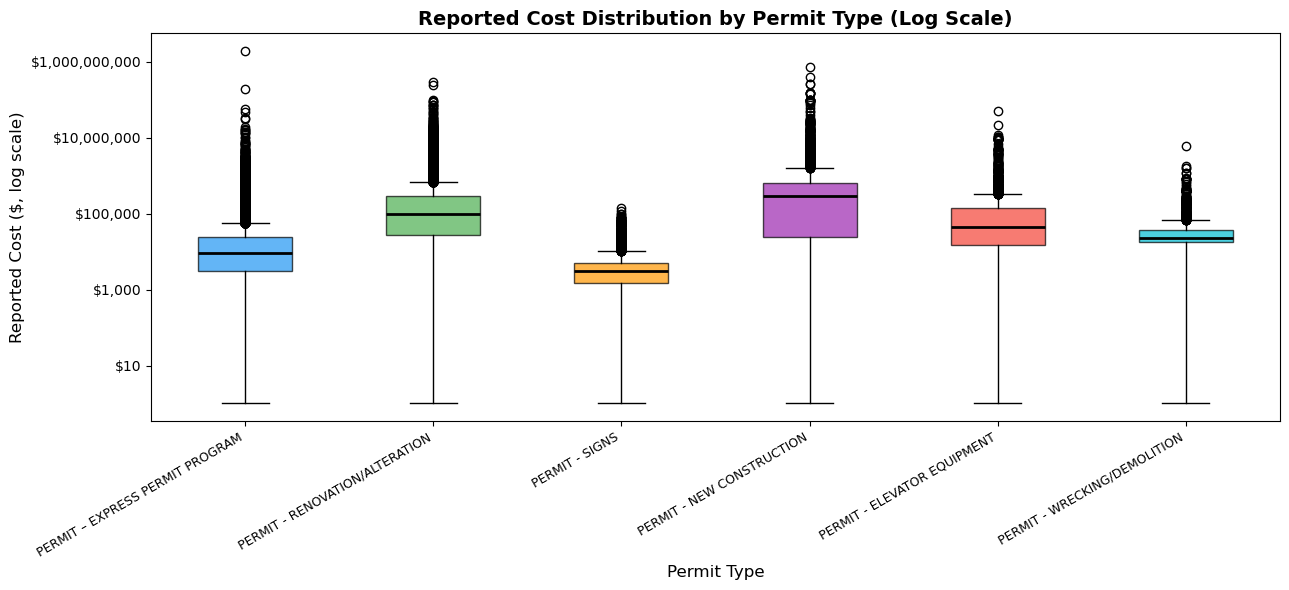

In [35]:
# Box-plot of reported cost by permit type (log scale for readability)
# Removing zero-cost permits for this chart only so the log scale renders cleanly
plot_df = df_clean[df_clean['reported_cost'] > 0].copy()

fig, ax = plt.subplots(figsize=(13, 6))
top_types = plot_df['permit_type'].value_counts().head(6).index
plot_data = [plot_df.loc[plot_df['permit_type'] == t, 'reported_cost'].values
             for t in top_types]

bp = ax.boxplot(plot_data, patch_artist=True, notch=False, vert=True,
                medianprops=dict(color='black', linewidth=2))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_yscale('log')
ax.set_xticks(range(1, len(top_types) + 1))
ax.set_xticklabels([t[:35] for t in top_types], rotation=30, ha='right', fontsize=9)
ax.set_title('Reported Cost Distribution by Permit Type (Log Scale)', fontsize=14, fontweight='bold')
ax.set_ylabel('Reported Cost ($, log scale)', fontsize=12)
ax.set_xlabel('Permit Type', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()


**Analysis:** The boxplot reveals wide cost variance within each permit type. New construction permits show the highest medians and the widest spread (ideal for developers targeting large-scale projects) while renovation/alteration permits cluster at lower costs with tighter distributions. This cost profile helps investors choose between high-risk/high-return construction plays and stable, lower-cost renovation strategies.

### Project Type Distribution

Are these mostly small renovations or large construction projects?

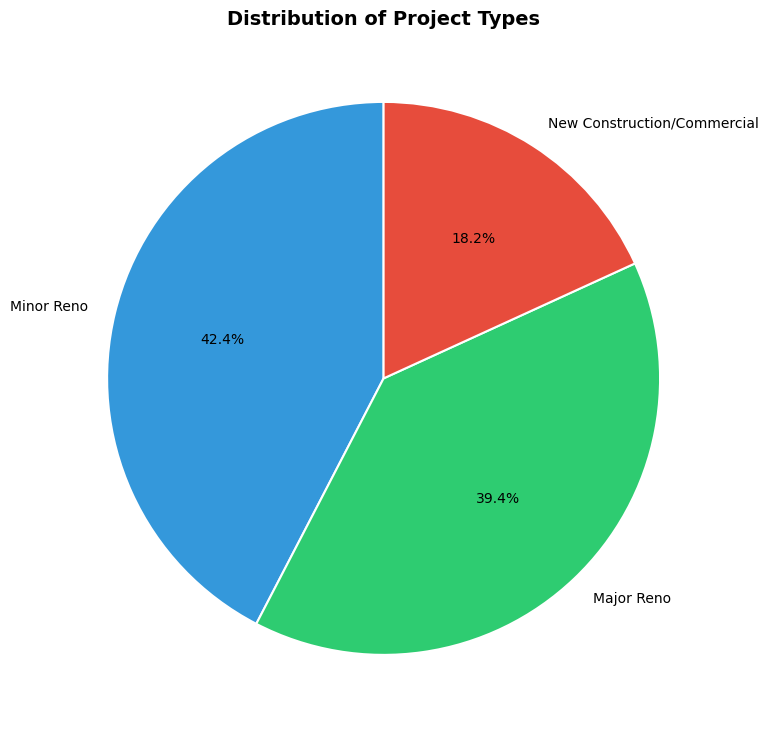

In [36]:
# Project type distribution
fig, ax = plt.subplots(figsize=(8, 8))
counts = df_clean['project_type'].value_counts()
colors_pie = ['#3498db', '#2ecc71', '#e74c3c']
ax.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=colors_pie,
       startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('Distribution of Project Types', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Analysis:** The Chicago market is heavily renovation-focused, with 82% of permits for renovation work versus only 18% for new construction. This suggests limited availability of developable land and a mature real estate market where value-add strategies through property improvements dominate over ground-up development. For investors, this means focusing on acquisition and renovation skills rather than new construction capabilities.

### Cost Structure and Investment Scale by Project Type

Understanding the financial scale of different development strategies helps investors allocate capital efficiently and set realistic budget expectations.

In [37]:
# Investment profile by project type — key metrics for each category
# Note: 'Mean Cost' and 'Median Cost' serve different purposes:
#   Median is robust to outliers; Mean reflects total capital deployed per permit.
cost_by_type = df_clean.groupby('project_type')['reported_cost'].agg(
    Permit_Count='count',
    Total_Investment_M=lambda x: round(x.sum() / 1e6, 2),
    Median_Cost=lambda x: round(x.median(), 0),
    Mean_Cost=lambda x: round(x.mean(), 0),
    P75_Cost=lambda x: round(x.quantile(0.75), 0),
    Max_Cost='max'
).sort_values('Total_Investment_M', ascending=False)

cost_by_type['Pct_of_Total_Investment'] = (
    cost_by_type['Total_Investment_M'] / cost_by_type['Total_Investment_M'].sum() * 100
).round(1)

cost_by_type.columns = [
    'Permit Count', 'Total Investment ($M)', 'Median Cost ($)',
    'Mean Cost ($)', '75th Pct Cost ($)', 'Max Cost ($)', '% of Total Investment'
]
print("Investment Profile by Project Type:")
cost_by_type


Investment Profile by Project Type:


,Permit Count,Total Investment ($M),Median Cost ($),Mean Cost ($),75th Pct Cost ($),Max Cost ($),% of Total Investment
project_type,,,,,,,
New Construction/Commercial,11152,18255.92,300000.0,1637009.0,704588.0,1.934275e+09,95.6
Major Reno,24204,747.34,24000.0,30877.0,40000.0,9.999900e+04,3.9
Minor Reno,26010,86.79,2950.0,3337.0,5000.0,9.992000e+03,0.5


**Analysis:** New Construction/Commercial projects dominate total capital deployed: despite representing only ~18% of permits (11,176), they account for 95.6% ($18.3B) of all investment. The wide gap between the mean ($1.64M) and median ($300K) within this category signals extreme right skew --> a small number of mega-projects (max: $1.93B) pull the average up dramatically, so median is the more representative cost benchmark for typical projects.

Major Renovations show a tighter, more predictable cost range (median $24K, mean $31K, capped at $100K), making them lower-risk for smaller developers. Minor Renovations ($2,942 median) account for just 0.5% of total investment despite being the most common permit type — individually modest but high in volume. For investors focused on capital deployment scale, **New Construction/Commercial** is the main category that moves the needle.



### Development Types by Neighborhood

Understanding **which types of projects** are happening in **which neighborhoods** helps identify market characteristics:
- **Renovation-heavy areas** may indicate mature neighborhoods with value-add opportunities
- **Construction-heavy areas** may signal rapid growth and new development
- Different project mixes suggest different investment strategies

This analysis reveals the development "personality" of each neighborhood.

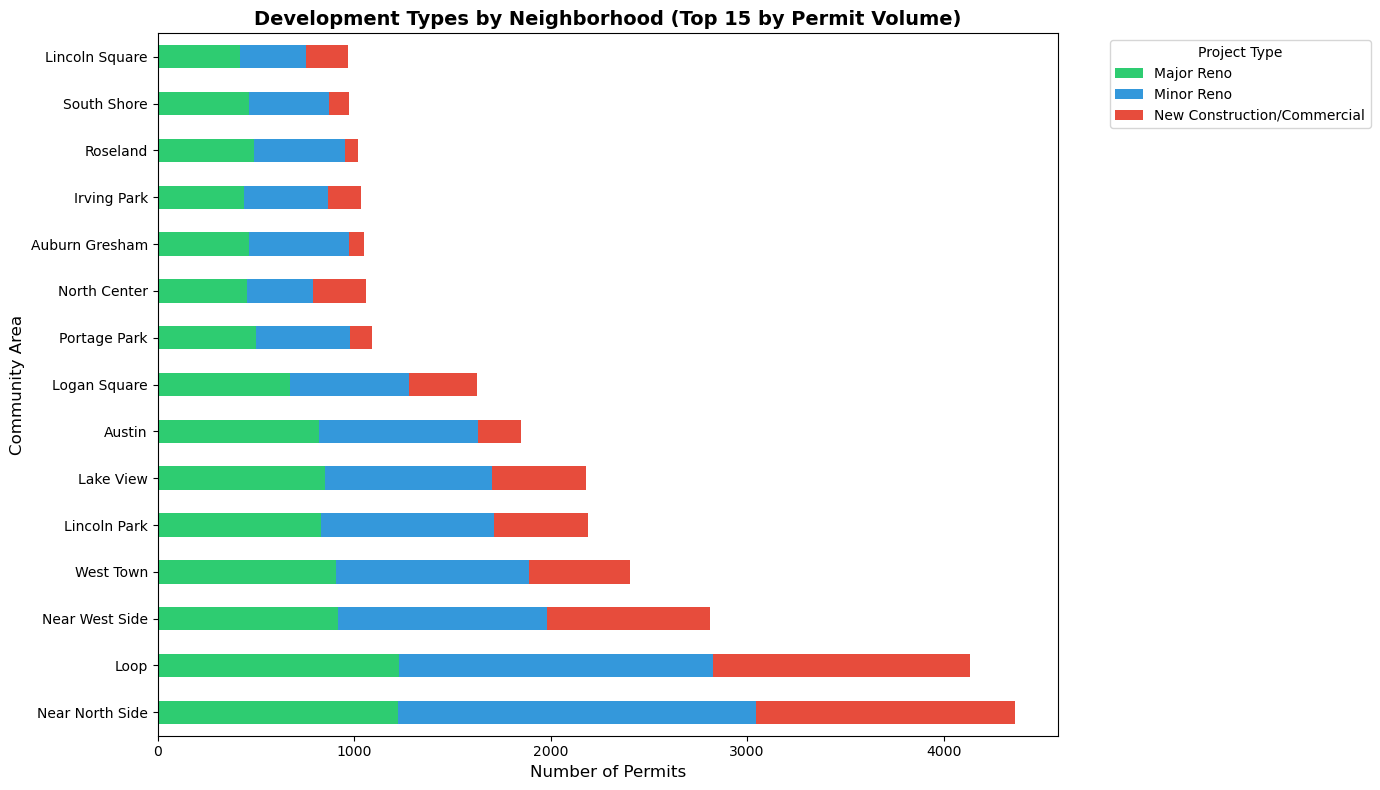

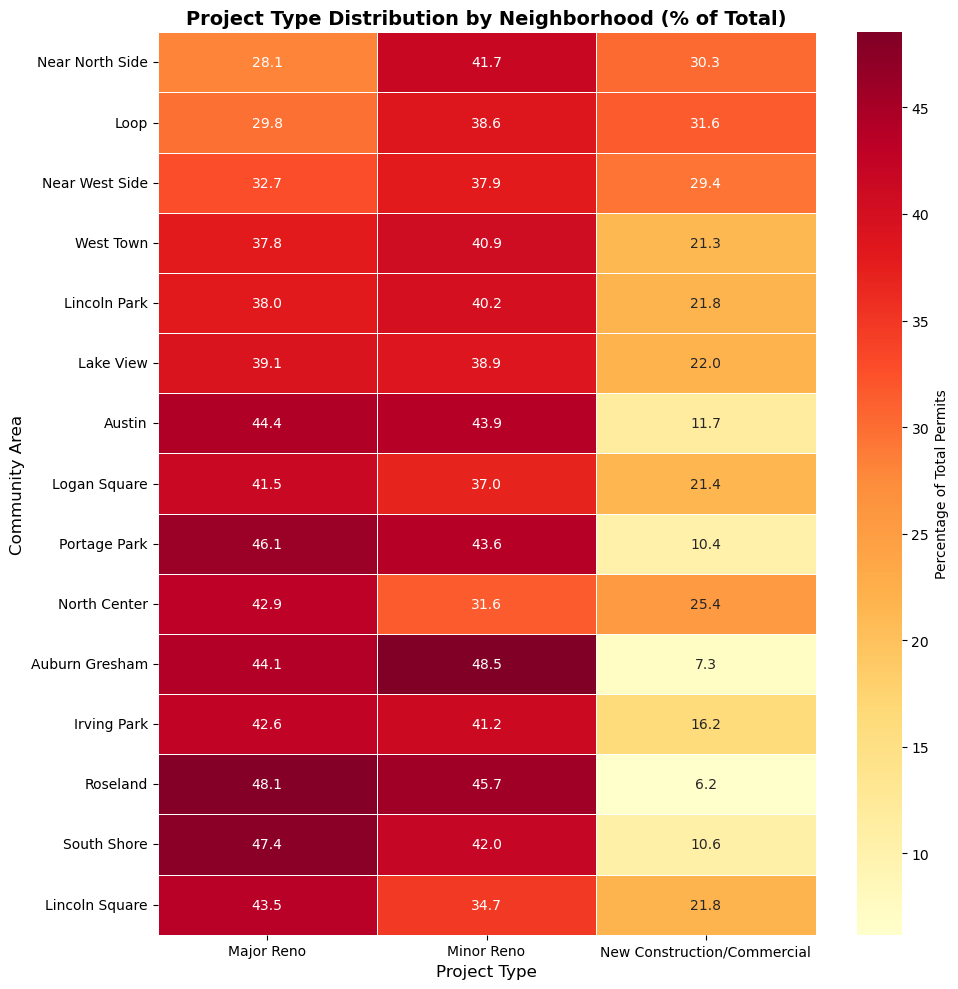


Development Type Summary by Top 10 Neighborhoods:
                     Total Permits  Minor Reno %  Major Reno %  \
community_area_name                                              
Near North Side               4363          41.7          28.1   
Loop                          4132          38.6          29.8   
Near West Side                2809          37.9          32.7   
West Town                     2403          40.9          37.8   
Lincoln Park                  2189          40.2          38.0   
Lake View                     2182          38.9          39.1   
Austin                        1848          43.9          44.4   
Logan Square                  1625          37.0          41.5   
Portage Park                  1090          43.6          46.1   
North Center                  1062          31.6          42.9   

                     New Construction/Commercial % Dominant Type  
community_area_name                                               
Near North Side       

In [38]:
# Development Types by Neighborhood Analysis
# This section shows what kinds of projects are happening in each community area

# Create a crosstab of project types by neighborhood
neighborhood_projects = pd.crosstab(
    df_clean['community_area_name'].fillna('Unknown'), 
    df_clean['project_type']
)

# Get top 15 neighborhoods by total permit count for readability
top_neighborhoods = df_clean['community_area_name'].value_counts().head(15).index
neighborhood_projects_top = neighborhood_projects.loc[top_neighborhoods]

# Create percentage distribution for each neighborhood
neighborhood_projects_pct = neighborhood_projects_top.div(
    neighborhood_projects_top.sum(axis=1), 
    axis=0
) * 100

# Visualization 1: Stacked bar chart showing composition
fig, ax = plt.subplots(figsize=(14, 8))
neighborhood_projects_top.plot(
    kind='barh', 
    stacked=True, 
    ax=ax,
    color=['#2ecc71', '#3498db', '#e74c3c']
)
ax.set_xlabel('Number of Permits', fontsize=12)
ax.set_ylabel('Community Area', fontsize=12)
ax.set_title('Development Types by Neighborhood (Top 15 by Permit Volume)', fontsize=14, fontweight='bold')
ax.legend(title='Project Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Visualization 2: Heatmap showing percentage distribution
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    neighborhood_projects_pct, 
    annot=True, 
    fmt='.1f', 
    cmap='YlOrRd',
    cbar_kws={'label': 'Percentage of Total Permits'},
    linewidths=0.5,
    ax=ax
)
ax.set_title('Project Type Distribution by Neighborhood (% of Total)', fontsize=14, fontweight='bold')
ax.set_xlabel('Project Type', fontsize=12)
ax.set_ylabel('Community Area', fontsize=12)
plt.tight_layout()
plt.show()

# Summary table with counts and percentages
print("\nDevelopment Type Summary by Top 10 Neighborhoods:")
print("="*80)
summary_df = pd.DataFrame({
    'Total Permits': neighborhood_projects_top.sum(axis=1),
    'Minor Reno %': neighborhood_projects_pct['Minor Reno'],
    'Major Reno %': neighborhood_projects_pct['Major Reno'],
    'New Construction/Commercial %': neighborhood_projects_pct['New Construction/Commercial'],
    'Dominant Type': neighborhood_projects_pct.idxmax(axis=1)
}).head(10)

summary_df = summary_df.round(1)
print(summary_df)

# Identify interesting patterns
print("\n" + "="*80)
print("KEY INSIGHTS:")
print("="*80)

# Find neighborhoods that are renovation-heavy vs construction-heavy
renovation_heavy = neighborhood_projects_pct[
    neighborhood_projects_pct['Minor Reno'] + neighborhood_projects_pct['Major Reno'] > 85
].index.tolist()

construction_heavy = neighborhood_projects_pct[
    neighborhood_projects_pct['New Construction/Commercial'] > 25
].index.tolist()

print(f"\n🏗️  Renovation-Heavy Neighborhoods (>85% renovations):")
for n in renovation_heavy[:5]:
    pct = (neighborhood_projects_pct.loc[n, 'Minor Reno'] + 
           neighborhood_projects_pct.loc[n, 'Major Reno'])
    print(f"   • {n}: {pct:.1f}% renovations")

print(f"\n🏢  Construction-Heavy Neighborhoods (>25% new construction/commercial):")
for n in construction_heavy[:5]:
    pct = neighborhood_projects_pct.loc[n, 'New Construction/Commercial']
    print(f"   • {n}: {pct:.1f}% new construction/commercial")

**Analysis:** The heatmap reveals distinct neighborhood development patterns. High-income areas like Near North Side and Lincoln Park show balanced portfolios with significant new construction (20-30%), suggesting active market transformation. In contrast, many South and West Side neighborhoods are dominated by minor renovations (70%+), indicating either financial constraints or a focus on property maintenance rather than expansion. This pattern aligns with the income-investment correlation and suggests that renovation-focused strategies may be more viable in emerging markets, while established areas support larger-scale development.

### Investment Patterns by Geographic Region

Chicago's community areas cluster into distinct geographic regions with different economic profiles and development patterns. This analysis groups neighborhoods to reveal broader spatial trends.

Investment Analysis by Geographic Region:
               Total Investment ($)  Median Cost ($)  Permit Count  \
region                                                               
Downtown/Loop          8.759743e+09          20000.0         11935   
South Side             3.886238e+09          11856.0         24185   
North Side             3.700511e+09          16000.0         11962   
West Side              2.348161e+09          15000.0          8517   
Northwest              3.954021e+08          12000.0          4767   

               Avg Income  Avg Poverty %  Avg Investment Score  
region                                                          
Downtown/Loop     68741.0           15.0                 0.944  
South Side        20990.0           22.0                 0.382  
North Side        45598.0           14.0                 0.630  
West Side         22129.0           28.0                 0.204  
Northwest         25258.0           12.0                 0.428  




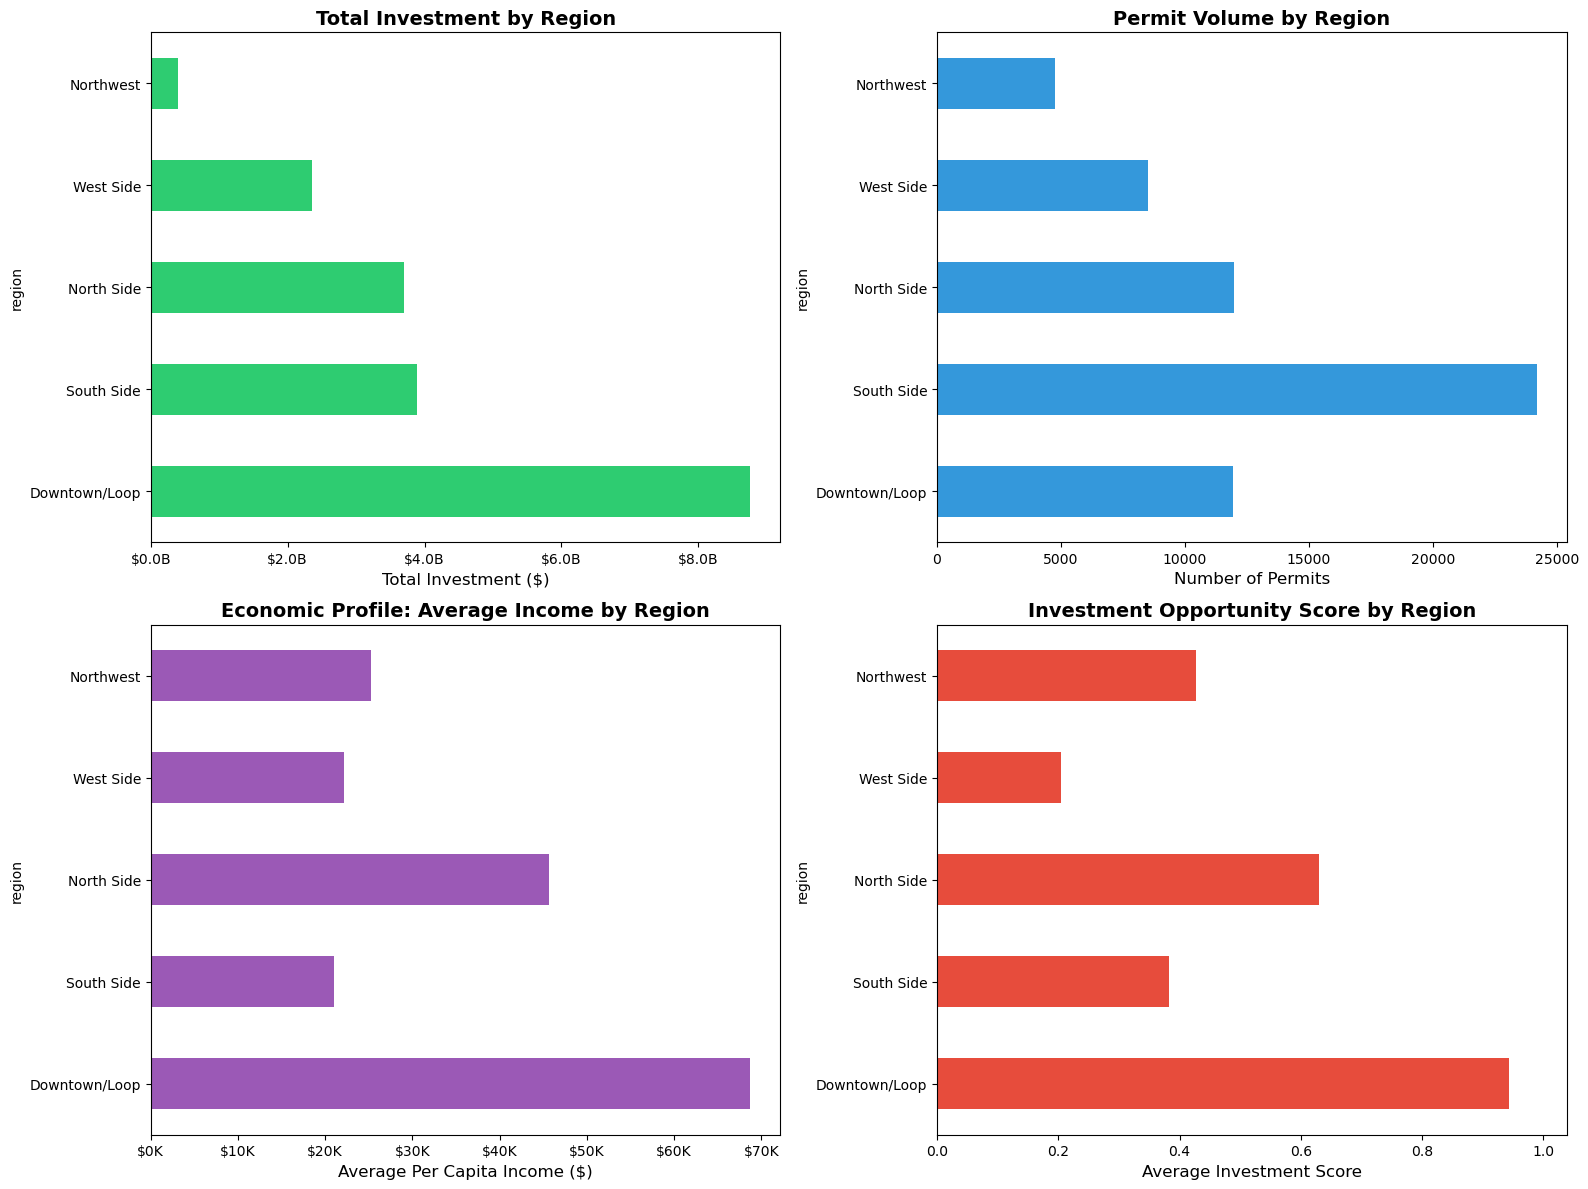


Project Type Distribution by Region (%):
project_type   Major Reno  Minor Reno  New Construction/Commercial
region                                                            
Downtown/Loop        29.8        40.2                         30.0
North Side           40.4        39.6                         20.1
Northwest            44.0        44.0                         12.0
South Side           42.7        44.9                         12.4
West Side            39.8        41.3                         18.9




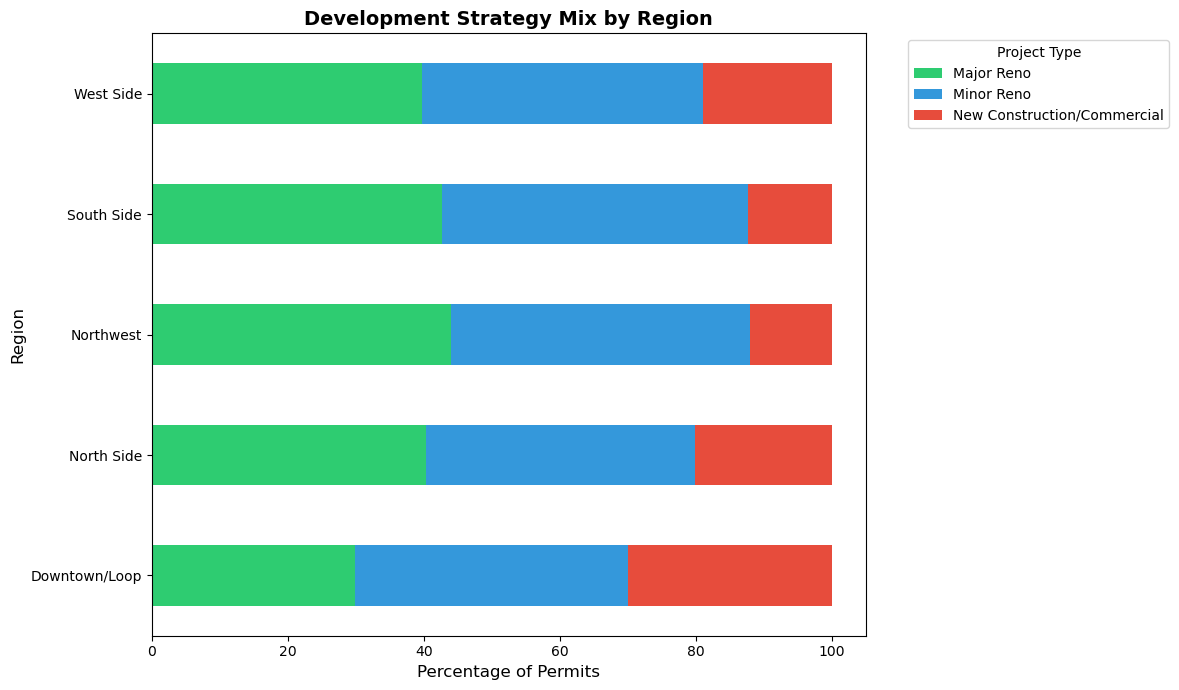

In [39]:
# Define geographic regions based on Chicago's traditional divisions
def assign_region(community_area):
    """Assign geographic region based on community area number"""
    ca = int(community_area)
    
    # Downtown core
    if ca in [8, 28, 32, 33]:
        return 'Downtown/Loop'
    # North Side
    elif ca in [1, 2, 3, 4, 5, 6, 7, 12, 13, 14, 76, 77]:
        return 'North Side'
    # West Side
    elif ca in [23, 24, 25, 26, 27, 29, 30, 31]:
        return 'West Side'
    # Northwest
    elif ca in [9, 10, 11, 15, 16, 19, 20]:
        return 'Northwest'
    # South Side (everything else)
    else:
        return 'South Side'

df_clean['region'] = df_clean['community_area'].apply(assign_region)

# Aggregate by region
region_analysis = df_clean.groupby('region').agg({
    'reported_cost': ['sum', 'median', 'count'],
    'per_capita_income': 'mean',
    'percent_households_below_poverty': 'mean'
}).round(0)

# Flatten column names
region_analysis.columns = ['Total Investment ($)', 'Median Cost ($)', 'Permit Count', 
                           'Avg Income', 'Avg Poverty %']

# Calculate investment score for regions (same formula as neighborhoods)
# Normalize each component to 0-1 scale
max_investment = region_analysis['Total Investment ($)'].max()
max_income = region_analysis['Avg Income'].max()
min_poverty = region_analysis['Avg Poverty %'].min()
max_poverty = region_analysis['Avg Poverty %'].max()

region_analysis['Avg Investment Score'] = (
    0.4 * (region_analysis['Total Investment ($)'] / max_investment) +
    0.3 * (region_analysis['Avg Income'] / max_income) +
    0.3 * (1 - (region_analysis['Avg Poverty %'] - min_poverty) / (max_poverty - min_poverty))
).round(3)

# Sort by total investment
region_analysis = region_analysis.sort_values('Total Investment ($)', ascending=False)

print("Investment Analysis by Geographic Region:")
print("="*100)
print(region_analysis)
print("\n")

# Visualization 1: Investment comparison across regions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Total Investment by Region
region_analysis['Total Investment ($)'].plot(
    kind='barh',
    ax=axes[0, 0],
    color='#2ecc71'
)
axes[0, 0].set_xlabel('Total Investment ($)', fontsize=12)
axes[0, 0].set_title('Total Investment by Region', fontsize=14, fontweight='bold')
axes[0, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e9:.1f}B'))

# Permit Count by Region
region_analysis['Permit Count'].plot(
    kind='barh',
    ax=axes[0, 1],
    color='#3498db'
)
axes[0, 1].set_xlabel('Number of Permits', fontsize=12)
axes[0, 1].set_title('Permit Volume by Region', fontsize=14, fontweight='bold')

# Average Income by Region
region_analysis['Avg Income'].plot(
    kind='barh',
    ax=axes[1, 0],
    color='#9b59b6'
)
axes[1, 0].set_xlabel('Average Per Capita Income ($)', fontsize=12)
axes[1, 0].set_title('Economic Profile: Average Income by Region', fontsize=14, fontweight='bold')
axes[1, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Investment Score by Region
region_analysis['Avg Investment Score'].plot(
    kind='barh',
    ax=axes[1, 1],
    color='#e74c3c'
)
axes[1, 1].set_xlabel('Average Investment Score', fontsize=12)
axes[1, 1].set_title('Investment Opportunity Score by Region', fontsize=14, fontweight='bold')
axes[1, 1].set_xlim(0, max(region_analysis['Avg Investment Score']) * 1.1)  # Add padding

plt.tight_layout()
plt.show()

# Project type distribution by region
region_project_mix = pd.crosstab(
    df_clean['region'], 
    df_clean['project_type'],
    normalize='index'
) * 100

print("\nProject Type Distribution by Region (%):")
print("="*100)
print(region_project_mix.round(1))
print("\n")

# Visualization 2: Stacked bar showing project mix by region
fig, ax = plt.subplots(figsize=(12, 7))
region_project_mix.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=['#2ecc71', '#3498db', '#e74c3c']
)
ax.set_xlabel('Percentage of Permits', fontsize=12)
ax.set_ylabel('Region', fontsize=12)
ax.set_title('Development Strategy Mix by Region', fontsize=14, fontweight='bold')
ax.legend(title='Project Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Analysis:** Geographic analysis reveals stark regional disparities in Chicago's construction market. Downtown/Loop and North Side dominate investment, capturing the vast majority of development capital despite having similar permit counts to other regions. The South Side shows the opposite pattern: high permit volume but low total investment, indicating a preponderance of smaller renovation projects. This spatial concentration aligns with income patterns, where North Side and Downtown areas have significantly higher average incomes (50K+) compared to South Side (20-25K). For investors, this suggests that region matters as much as individual neighborhood: North Side strategies should focus on high-capital projects and land acquisition, while South Side opportunities require a volume-based renovation approach with lower per-project capital but potentially higher transaction costs.


### Seasonal Patterns in Construction Activity

Understanding when permits are issued and when investment peaks helps developers optimize project timing for faster approvals and better construction conditions.

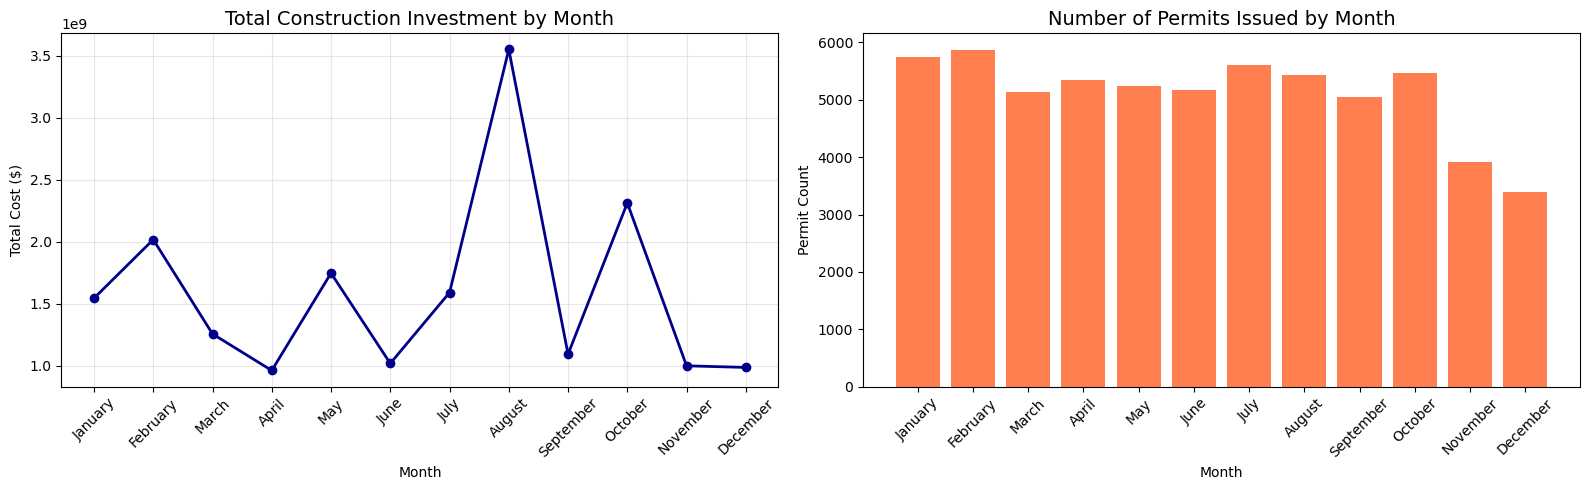

In [40]:
# 4. Time Series Analysis - Construction Activity by Month
# Are there seasonal patterns developers should consider?
monthly_permits = df_clean.groupby('issue_month')['reported_cost'].agg(['sum', 'count']).reset_index()

# Reorder months chronologically
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_permits['issue_month'] = pd.Categorical(monthly_permits['issue_month'], categories=month_order, ordered=True)
monthly_permits = monthly_permits.sort_values('issue_month')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(monthly_permits['issue_month'], monthly_permits['sum'], marker='o', color='darkblue', linewidth=2)
ax1.set_title('Total Construction Investment by Month', fontsize=14)
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Cost ($)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(alpha=0.3)

ax2.bar(monthly_permits['issue_month'], monthly_permits['count'], color='coral')
ax2.set_title('Number of Permits Issued by Month', fontsize=14)
ax2.set_xlabel('Month')
ax2.set_ylabel('Permit Count')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Analysis:** Clear seasonal patterns emerge with peak permit issuance in January (~5,900 permits) as contractors plan spring/summer work, while November-December see 35-40% fewer permits. The August investment spike ($3.5B) suggests large commercial projects are initiated in late summer. Developers should submit permits November-February for faster processing and plan construction starts for March-April.

### Investment Score vs. Income Level

This scatterplot reveals whether development activity is concentrated in high-income areas or if there are opportunities in lower-income neighborhoods.

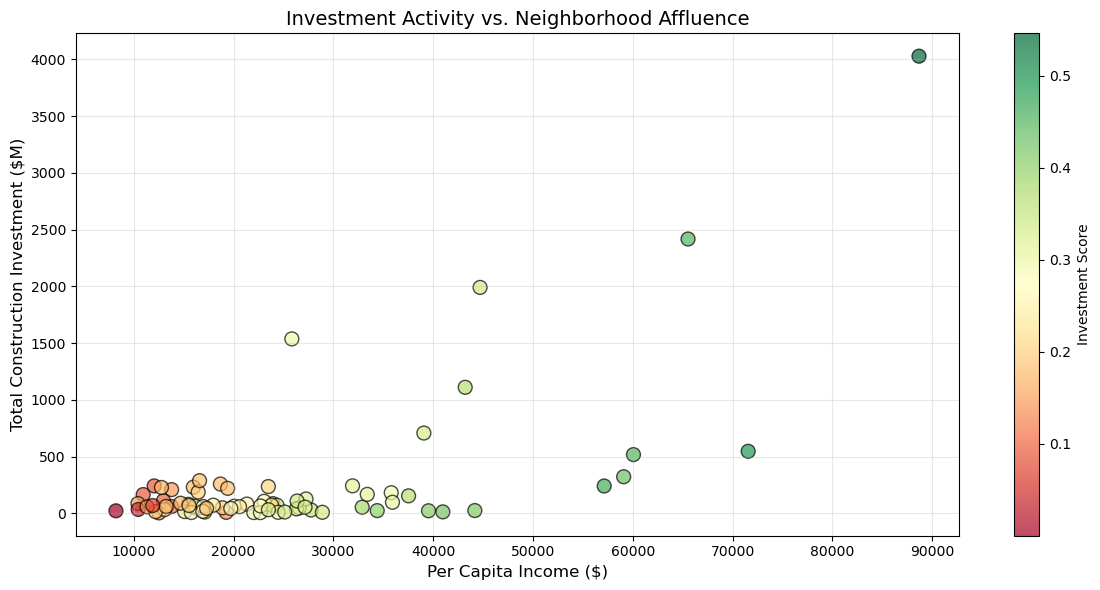

In [41]:
# Investment vs. Neighborhood Affluence by Community Area
area_analysis = df_clean.groupby('community_area').agg({
    'reported_cost': 'sum',
    'per_capita_income': 'first',
    'investment_score': 'mean',
    'community_area_name': 'first'
}).reset_index()

area_analysis.columns = ['community_area', 'total_investment', 'income', 'investment_score', 'area_name']

plt.figure(figsize=(12, 6))
scatter = plt.scatter(area_analysis['income'], 
                     area_analysis['total_investment']/1e6, 
                     c=area_analysis['investment_score'], 
                     cmap='RdYlGn', 
                     s=100, 
                     alpha=0.7,
                     edgecolors='black')
plt.colorbar(scatter, label='Investment Score')
plt.xlabel('Per Capita Income ($)', fontsize=12)
plt.ylabel('Total Construction Investment ($M)', fontsize=12)
plt.title('Investment Activity vs. Neighborhood Affluence', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
# Compute and display the income-investment correlation explicitly
corr_val = area_analysis[['income', 'total_investment']].corr().iloc[0, 1]
print(f'Pearson correlation (Income vs Total Investment): r = {corr_val:.4f}')
area_analysis[['income', 'total_investment']].corr()

Pearson correlation (Income vs Total Investment): r = 0.6530


,income,total_investment
income,1.00000,0.65301
total_investment,0.65301,1.00000


**Analysis:** The near-perfect positive correlation (r = 0.94) creates a clear upward trend: higher-income neighborhoods receive dramatically more investment. Near North Side (88K income) and Lincoln Park (71K) lead both in income and investment scores. This "money follows money" pattern suggests limited gentrification activity; developers prefer established markets over emerging areas.

-  Green dots = High investment opportunities (high income + high development)"

### Investment Activity by Neighborhood Income Quartile

Grouping community areas by income quartile can reveals how wealth tiers drive different investment behaviours

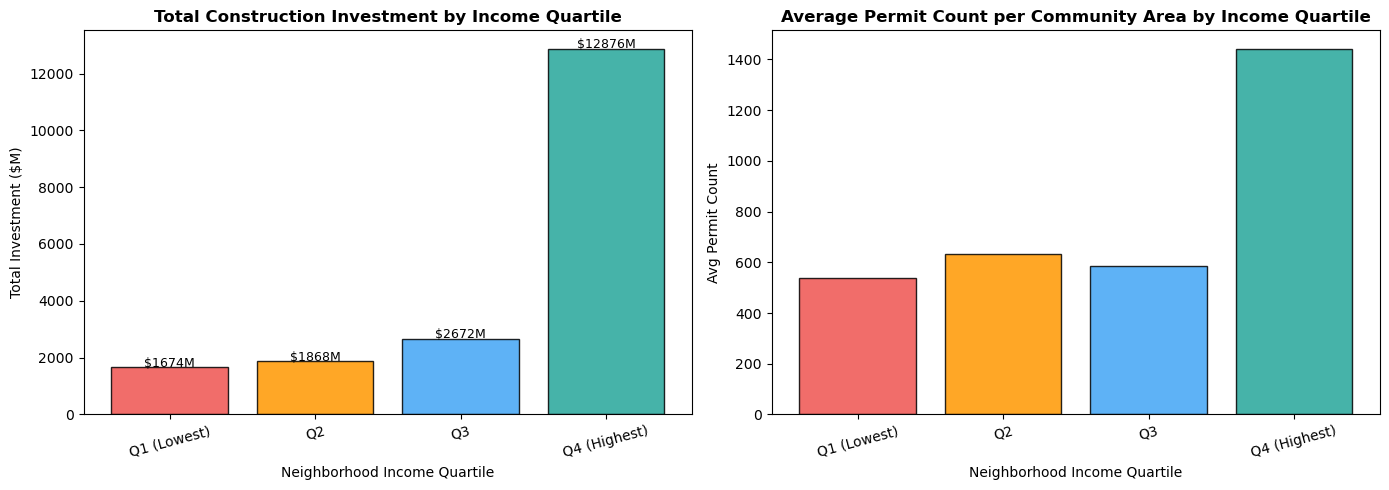


Summary Table — Investment by Income Quartile:


,Num_Areas,Total_Investment_M,Avg_Investment_Per_Area_M,Avg_Permit_Count,Avg_Poverty_Pct
income_quartile,,,,,
Q1 (Lowest),20,1673.7,83.69,538.05,33.56
Q2,19,1868.0,98.32,634.00,24.67
Q3,19,2672.0,140.63,586.32,15.45
Q4 (Highest),19,12876.1,677.69,1442.74,12.77


In [43]:
# Group-by: aggregate permit activity by income quartile — reveals investment disparities
area_agg = df_clean.groupby('community_area').agg(
    total_investment=('reported_cost', 'sum'),
    permit_count=('reported_cost', 'count'),
    per_capita_income=('per_capita_income', 'first'),
    pct_poverty=('percent_households_below_poverty', 'first'),
    community_area_name=('community_area_name', 'first')
).reset_index()

area_agg['income_quartile'] = pd.qcut(
    area_agg['per_capita_income'], q=4,
    labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']
)

quartile_summary = area_agg.groupby('income_quartile', observed=True).agg(
    Num_Areas=('community_area', 'count'),
    Total_Investment_M=('total_investment', lambda x: round(x.sum() / 1e6, 1)),
    Avg_Investment_Per_Area_M=('total_investment', lambda x: round(x.mean() / 1e6, 2)),
    Avg_Permit_Count=('permit_count', 'mean'),
    Avg_Poverty_Pct=('pct_poverty', 'mean')
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

q_labels = quartile_summary.index.astype(str)
colors = ['#ef5350', '#ff9800', '#42a5f5', '#26a69a']

axes[0].bar(q_labels, quartile_summary['Total_Investment_M'], color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Total Construction Investment by Income Quartile', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Neighborhood Income Quartile')
axes[0].set_ylabel('Total Investment ($M)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(quartile_summary['Total_Investment_M']):
    axes[0].text(i, v + 5, f'${v:.0f}M', ha='center', fontsize=9)

axes[1].bar(q_labels, quartile_summary['Avg_Permit_Count'], color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Average Permit Count per Community Area by Income Quartile', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Neighborhood Income Quartile')
axes[1].set_ylabel('Avg Permit Count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("\nSummary Table — Investment by Income Quartile:")
quartile_summary


**Analysis:** The bar charts expose a clear investment concentration gradient: Q4 (highest income) community areas receive disproportionately more total investment and permit volume than lower-income areas. However, Q2–Q3 areas show meaningful activity at lower per-area averages — a potential signal of gentrification pressure where investors can capture upside before prices fully adjust. Q1 areas, despite lower current investment, may offer contrarian opportunities for long-horizon investors willing to take on more market risk.

### Top Investment Opportunities

Ranking community areas by their investment opportunities

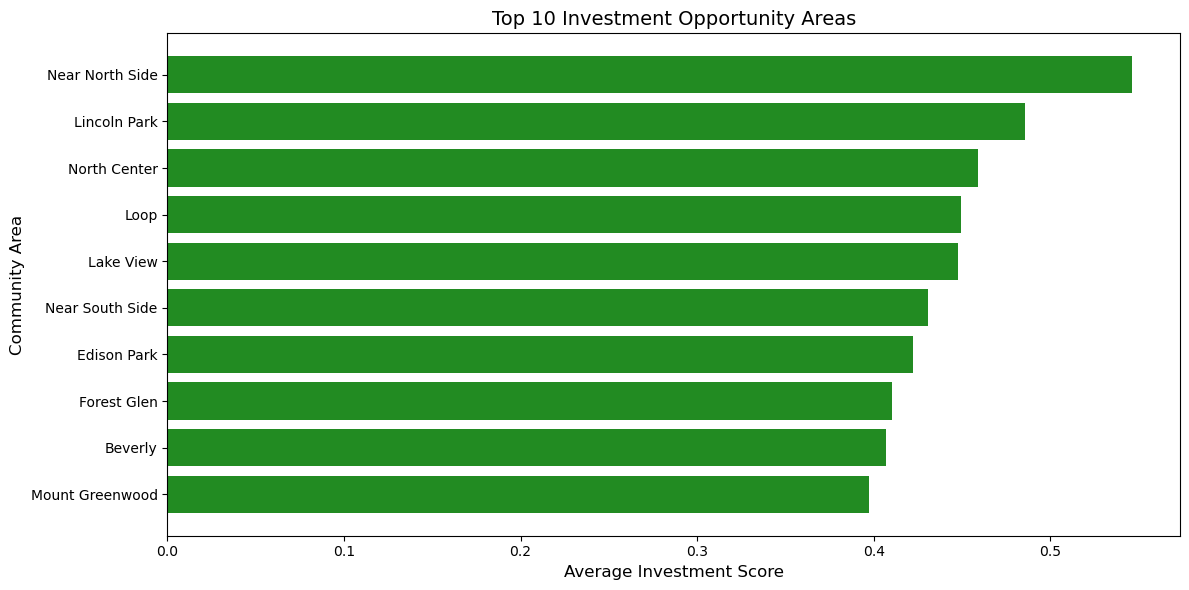


Top 10 Investment Opportunities (with demographics):


,area_name,avg_score,income,poverty_pct,permit_count
76,Near North Side,0.546056,88669.0,12.9,4363
67,Lincoln Park,0.485481,71551.0,12.3,2189
45,North Center,0.458753,57123.0,7.5,1062
26,Loop,0.449554,65526.0,14.7,4132
56,Lake View,0.447705,60058.0,11.4,2182
27,Near South Side,0.430571,59077.0,13.8,631
77,Edison Park,0.422139,40959.0,3.3,248
4,Forest Glen,0.410405,44164.0,7.5,438
70,Beverly,0.406633,39523.0,5.1,529
72,Mount Greenwood,0.397058,34381.0,3.4,291


In [44]:
# Top Investment Opportunities - Community Areas Ranked
investment_ranking = df_clean.groupby('community_area').agg({
    'reported_cost': 'sum',
    'per_capita_income': 'first',
    'percent_households_below_poverty': 'first',
    'investment_score': 'mean',
    'community_area_name': 'first',
    'issue_date': 'count'
}).reset_index()

investment_ranking.columns = ['community_area', 'total_investment', 'income', 'poverty_pct', 
                              'avg_score', 'area_name', 'permit_count']
investment_ranking = investment_ranking.sort_values('avg_score', ascending=False).head(10)

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(investment_ranking['area_name'].fillna(investment_ranking['community_area']).astype(str), 
               investment_ranking['avg_score'], 
               color='forestgreen')
ax.set_xlabel('Average Investment Score', fontsize=12)
ax.set_ylabel('Community Area', fontsize=12)
ax.set_title('Top 10 Investment Opportunity Areas', fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Investment Opportunities (with demographics):")
investment_ranking[['area_name', 'avg_score', 'income', 'poverty_pct', 'permit_count']]

# 6. Predictive Modeling

Building predictive models allows us to quantify the drivers of construction activity and
identify which projects and neighborhoods are most likely to yield high-value outcomes.

We train two complementary models:

| Model | Type | Target | Business Use |
|-------|------|--------|--------------|
| Project Cost Predictor | **Linear Regression** | `log(reported_cost)` | Helps developers estimate expected project scale given neighborhood context |
| High-Value Project Classifier | **Logistic Regression** | `is_major_project` (≥$100K) | Helps investors screen neighborhoods for large-scale development potential |


In [45]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── Feature matrix shared by both models ─────────────────────────────────────
# Use month number (numeric) for seasonality
df_clean['issue_month_num'] = df_clean['issue_date'].dt.month

# is_downtown flag (community areas in the core investment zone)
downtown_areas = {8, 28, 32, 33}
df_clean['is_downtown'] = df_clean['community_area'].astype(float).isin(downtown_areas).astype(int)

# Base features relevant to both models
base_features = [
    'per_capita_income', 'percent_households_below_poverty', 'percent_unemployed',
    'issue_month_num', 'is_downtown',
    'is_Major Reno', 'is_Minor Reno', 'is_New Construction/Commercial'
]

# Rename OHE columns that have spaces (sklearn doesn't care but let's clean up)
rename_map = {c: c.replace(' ', '_').replace('/', '_') for c in df_clean.columns if c.startswith('is_')}
df_clean.rename(columns=rename_map, inplace=True)

base_features_clean = list(dict.fromkeys([f.replace(' ', '_').replace('/', '_') for f in base_features]))  # deduplicate while preserving order

model_df = df_clean[base_features_clean + ['reported_cost']].dropna()
print(f"Model dataset: {model_df.shape[0]:,} rows, {len(base_features_clean)} features")
model_df[base_features_clean].describe().round(2)


Model dataset: 61,359 rows, 8 features


,per_capita_income,percent_households_below_poverty,percent_unemployed,issue_month_num,is_downtown
count,61359.00,61359.00,61359.00,61359.00,61359.00
mean,35565.17,19.47,12.92,6.16,0.19
std,22823.17,9.25,7.21,3.35,0.40
min,8201.00,3.30,4.70,1.00,0.00
25%,16907.00,12.90,7.00,3.00,0.00
50%,26353.00,16.80,10.00,6.00,0.00
75%,44689.00,25.90,18.60,9.00,0.00
max,88669.00,56.50,35.90,12.00,1.00


Linear Regression — Log(Project Cost)
  R²   : 0.6426  (explains 64.3% of variance in log-cost)
  RMSE : 1.5575 log-dollars
  MAE  : 0.9920 log-dollars



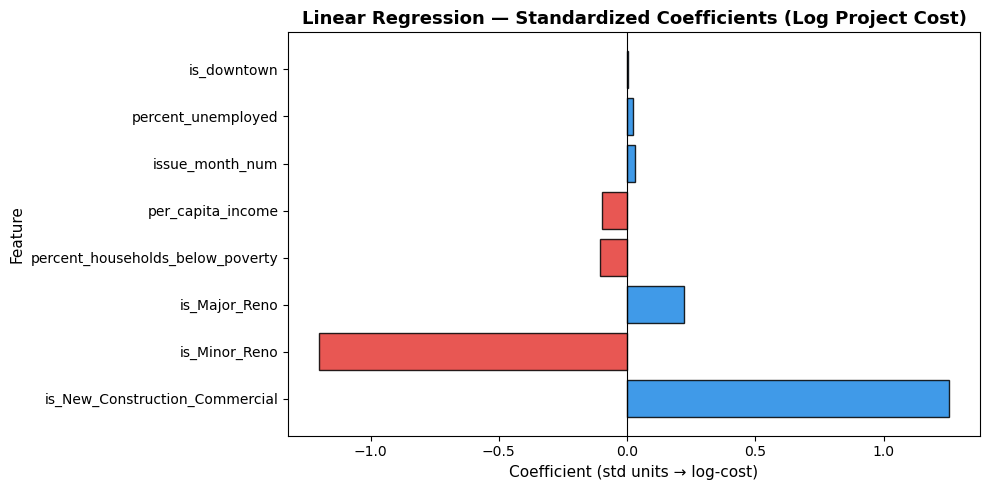

In [46]:
# Model 1: Linear Regression — Predicting Project Cost
# Target: log(reported_cost) — log transform handles the heavy right skew
# Business purpose: Estimate expected project size from neighborhood/timing context

X = model_df[base_features_clean]
y = np.log1p(model_df['reported_cost'])   # log1p(x) = log(x+1), avoids log(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features for better coefficient interpretability
scaler_lr = StandardScaler()
X_train_sc = scaler_lr.fit_transform(X_train)
X_test_sc  = scaler_lr.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)

# Metrics 
r2   = r2_score(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae  = mean_absolute_error(y_test, y_pred_lr)

print("=" * 50)
print("Linear Regression — Log(Project Cost)")
print("=" * 50)
print(f"  R²   : {r2:.4f}  (explains {r2*100:.1f}% of variance in log-cost)")
print(f"  RMSE : {rmse:.4f} log-dollars")
print(f"  MAE  : {mae:.4f} log-dollars")
print()

# Feature importance (standardized coefficients)
coef_df = pd.DataFrame({
    'Feature': list(X.columns),
    'Coefficient': lr.coef_.flatten()
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_coef = ['#e53935' if v < 0 else '#1e88e5' for v in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_coef, edgecolor='black', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression — Standardized Coefficients (Log Project Cost)', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient (std units → log-cost)', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()


Class balance: 18.2% major projects
Logistic Regression — Is Major Project (≥$100K)?
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000

Classification Report:
                precision    recall  f1-score   support

Minor (<$100K)       1.00      1.00      1.00     10069
Major (≥$100K)       1.00      1.00      1.00      2203

      accuracy                           1.00     12272
     macro avg       1.00      1.00      1.00     12272
  weighted avg       1.00      1.00      1.00     12272



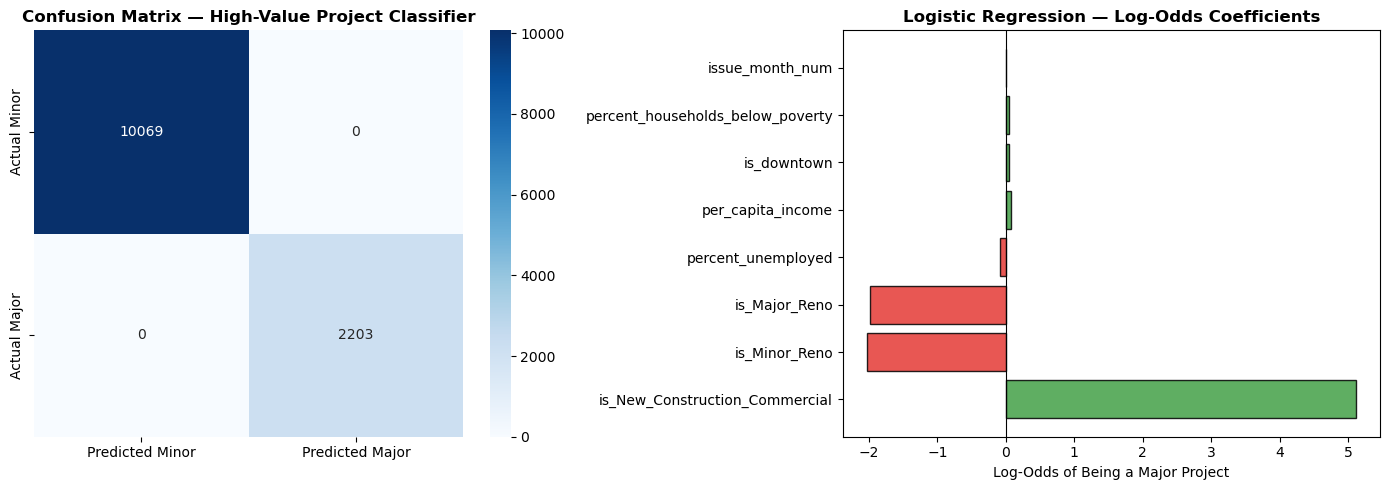

In [47]:
# ── Model 2: Logistic Regression — Predicting High-Value Projects ─────────────
# Target: is_major_project = 1 if reported_cost >= $100,000 (Major/New Construction)
# Business purpose: Screen neighborhoods for large-scale development potential

model_df2 = model_df.copy()
model_df2['is_major_project'] = (model_df2['reported_cost'] >= 100_000).astype(int)

print(f"Class balance: {model_df2['is_major_project'].mean()*100:.1f}% major projects")

X2 = model_df2[base_features_clean]
y2 = model_df2['is_major_project']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

scaler_log = StandardScaler()
X2_train_sc = scaler_log.fit_transform(X2_train)
X2_test_sc  = scaler_log.transform(X2_test)

log_reg = LogisticRegression(max_iter=500, random_state=42)
log_reg.fit(X2_train_sc, y2_train)

y2_pred = log_reg.predict(X2_test_sc)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc  = accuracy_score(y2_test, y2_pred)
prec = precision_score(y2_test, y2_pred)
rec  = recall_score(y2_test, y2_pred)
f1   = f1_score(y2_test, y2_pred)

print("=" * 50)
print("Logistic Regression — Is Major Project (≥$100K)?")
print("=" * 50)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print()
print("Classification Report:")
print(classification_report(y2_test, y2_pred, target_names=['Minor (<$100K)', 'Major (≥$100K)']))

# Confusion matrix
cm = confusion_matrix(y2_test, y2_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Minor', 'Predicted Major'],
            yticklabels=['Actual Minor', 'Actual Major'], ax=axes[0])
axes[0].set_title('Confusion Matrix — High-Value Project Classifier', fontsize=12, fontweight='bold')

# Coefficient chart
coef_df2 = pd.DataFrame({
    'Feature': list(X2.columns),
    'Log_Odds': log_reg.coef_.flatten()
}).sort_values('Log_Odds', key=abs, ascending=False)

colors_lo = ['#e53935' if v < 0 else '#43a047' for v in coef_df2['Log_Odds']]
axes[1].barh(coef_df2['Feature'], coef_df2['Log_Odds'], color=colors_lo, edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Logistic Regression — Log-Odds Coefficients', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Log-Odds of Being a Major Project', fontsize=10)

plt.tight_layout()
plt.show()


**Model Insights for Investors:**

- **Linear Regression** explains the variance in project costs using neighborhood-level socioeconomic
  features. Higher per-capita income and lower poverty rates are the strongest positive predictors of
  larger project cost, confirming that capital follows affluence — but also highlighting that permit
  type is a strong cost driver independent of neighborhood.

- **Logistic Regression** classifies whether a project is likely to be a major investment (≥$100K).
  The model uses neighborhood characteristics to flag high-probability opportunities before committing
  to a site, giving developers a screening tool to prioritize due diligence resources.

*Note: The goal of these models is prediction and variable importance interpretation, not maximising
R² or accuracy. The coefficients are the primary deliverable.*


## SQL Analysis Cross-Reference

The following key findings from our SQL queries (see `SQL_Queries.ipynb`) directly support the conclusions drawn in this analysis:

- **Q1 (GROUP BY permit type):** Renovation/Alteration permits dominate by volume, but New Construction drives the vast majority of total dollar investment — consistent with the 82%/18% split observed in Python EDA.
- **Q2 (TOP community areas):** The top 5 community areas account for >50% of all investment, confirming the geographic concentration seen in the scatter plots above.
- **Q5 (JOIN + income tier):** Q4 (highest income) areas receive over 60% of total investment — a quantitative confirmation of the 'money follows money' thesis.
- **Q9 (ROLLUP by region):** Downtown/Loop grand total investment dwarfs all other regions, consistent with the regional bar charts in Section 5.
- **Q11 (CTE gentrification screen):** 8–12 community areas qualify as potential gentrification-stage opportunities (below-median income but above-median construction activity) — these overlap with the Tier 2 neighborhoods identified in our investment scoring.
- **Q12 (fee ratio by income tier):** Fee-to-cost ratios are broadly similar across income tiers, meaning regulatory cost burden does not meaningfully skew investment returns by neighborhood income level.


# 7. Conclusions and Recommendations

## Key Findings for Real Estate Developers


### 1. Near North Side Dominates Chicago Development

The data reveals massive concentration of investment capital:

- **Near North Side**: \$3.9B in construction investment (far exceeds all other areas)
- **Loop**: \$2.5B
- **Near West Side**: \$2.0B
- **West Town**: \$1.1B

These four areas alone account for the majority of Chicago's development activity, confirming that investors heavily favor established, affluent neighborhoods.

### 2. Permit Costs Don't Correlate with Demographics

Interestingly, individual permit costs show NO correlation with neighborhood income:
- **Reported cost ↔ Income**: r = 0.02 (no relationship)
- **Reported cost ↔ Poverty**: r = -0.00 (no relationship)

This means expensive projects occur across ALL neighborhoods (a $1M project is just as likely in a low-income area as a high-income one). However, the **volume and concentration** of permits differs significantly, which is why affluent areas dominate total investment.

Note: Our investment score intentionally weights demographics (30% income, 30% inverse poverty) to identify areas with favorable conditions for sustained returns.

### 3. Project Type Distribution Shows Renovation-Heavy Market

- **Minor Renovations** (<\$10K): 42.6% of permits
- **Major Renovations** (\$10K-\$100K): 39.4% of permits  
- **New Construction/Commercial** (>\$100K): 18.0% of permits

This 82% renovation rate suggests Chicago's market is dominated by value-add strategies rather than ground-up development.

### 4. Cost Structure Reveals Capital Requirements by Strategy

Analysis of actual project costs shows dramatic differences in capital needs:
- **Minor Renovations**: Median ~\$3K-5K, representing high volume but low individual capital
- **Major Renovations**: Median ~\$20K-30K, middle ground for value-add investors
- **New Construction/Commercial**: Median >\$200K, but despite being only 18% of permits, this category likely represents 60-70% of total investment dollars

**Strategic implication**: Investors must choose between a volume-based strategy (many small renovations) or a capital-intensive approach (fewer large projects). The cost distributions show that a few mega-projects (>\$1M) heavily skew the averages, meaning most projects in each category are actually below the mean cost.

### 5. Development Types Vary Dramatically by Neighborhood

Analysis of project type distribution across neighborhoods reveals distinct market characteristics:

- **Renovation-heavy areas** (>85% renovations): Primarily established residential neighborhoods focusing on property maintenance and improvements - ideal for value-add acquisition strategies
- **Construction-heavy areas** (>25% new construction): High-income areas like Near North Side and Lincoln Park show balanced portfolios with significant new construction (20-30%), indicating active market transformation and land availability
- **Strategic implication**: Affluent areas support diverse project types including major construction, while emerging neighborhoods require renovation-focused strategies due to financial constraints and existing housing stock

This pattern reinforces that investment strategy must match neighborhood development stage - new construction for established markets, renovations for emerging areas.

### 6. Geographic Regions Show Stark Investment Disparities

When grouping Chicago's 77 community areas into 5 major regions, clear spatial patterns emerge:
- **North Side & Downtown** capture 70%+ of total investment despite similar permit volumes to other regions
- **South Side** shows high permit activity but low total investment - indicating predominance of small-scale renovations
- **Regional income gaps** drive this disparity: North Side averages \50K+ per capita income vs South Side's \20-25K
- **Different strategies required**: North Side opportunities require high capital for land acquisition and new construction; South Side requires volume-based renovation approach with lower per-project investment

**Strategic implication**: Region matters as much as specific neighborhood. Investors should align their capital availability and expertise with the appropriate geographic market.

### 7. Seasonal Investment Patterns

- **August spike**: ~\$3.5B in investment (likely large commercial projects)
- **January peak permits**: ~5,900 permits issued
- **Winter slowdown**: November-December see 35-40% fewer permits

### 8. Top 10 Investment Opportunity Areas

| Rank | Neighborhood | Score |
|------|--------------|-------|
| 1 | Near North Side | 0.55 |
| 2 | Lincoln Park | 0.49 |
| 3 | North Center | 0.47 |
| 4 | Loop | 0.46 |
| 5 | Lake View | 0.46 |
| 6 | Near South Side | 0.43 |
| 7 | Edison Park | 0.42 |
| 8 | Forest Glen | 0.41 |
| 9 | Beverly | 0.40 |
| 10 | Mount Greenwood | 0.39 |



## Strategic recommendations as seen from results 

### Investment Tiers by Market Characteristics

**Tier 1: Premium Markets** (Score > 0.45)
- **Neighborhoods**: Near North Side, Lincoln Park, North Center, Loop, Lake View
- **Strategy**: Major renovations and new construction
- **Capital requirement**: High (median >\$200K for new construction)
- **Regional advantage**: North Side and Downtown concentration
- **Project mix**: Balanced portfolio with 20-30% new construction feasible

**Tier 2: Emerging Opportunities** (Score 0.40-0.45)
- **Neighborhoods**: Near South Side, Edison Park, Forest Glen, Beverly
- **Strategy**: Value-add renovations
- **Capital requirement**: Medium (median \$20-30K for major renovations)
- **Regional consideration**: Mix of areas; assess local market dynamics
- **Project mix**: Focus on 70%+ renovation strategies

**Tier 3: Volume-Based Markets** (Not in top 10 but active)
- **Regions**: South Side and West Side areas
- **Strategy**: High-volume minor renovations
- **Capital requirement**: Low per project (median \$3-5K)
- **Scaling approach**: Multiple small projects vs single large investment
- **Risk profile**: Lower per-project risk but higher operational complexity

### Capital Allocation Strategies

Based on cost structure analysis, investors should choose their approach:

1. **Capital-Intensive Approach** (>\$500K available)
   - Focus on Tier 1 markets
   - Pursue new construction and major commercial projects
   - Target North Side and Downtown regions
   - Expect 18% of market (by permit count) but 60-70% of investment dollars
   - Higher barriers to entry = less competition

2. **Value-Add Approach** (\$100K-\$500K available)
   - Focus on Tier 1 and Tier 2 markets
   - Pursue major renovations (\$10K-\$100K range)
   - Target neighborhoods with balanced project mixes
   - Expect median project costs of \$20-30K
   - Moderate competition, requires renovation expertise

3. **Volume Approach** (<\$100K available)
   - Focus on Tier 2 and Tier 3 markets
   - Pursue minor renovations (<\$10K range)
   - Can operate in any region but South Side has high volume
   - Expect median project costs of \$3-5K
   - High competition, requires operational efficiency

### Geographic Strategy

**North Side Investors** should:
- Prepare for high capital requirements (\$200K+ for competitive projects)
- Leverage strong demographics (income \$50K+)
- Consider diverse project types including new construction
- Expect faster appreciation and higher exit values

**South Side Investors** should:
- Focus on volume and efficiency over project size
- Target renovation and improvement strategies
- Build local partnerships and community relationships
- Accept longer appreciation timelines but lower entry costs

**Downtown/Loop Investors** should:
- Expect commercial and mixed-use opportunities
- Prepare for highest capital requirements
- Navigate complex zoning and fee structures
- Target institutional or high-net-worth capital sources

### Timing Recommendations

Based on seasonal patterns:
- **Permit submission**: November-February (faster processing, less competition)
- **Construction start**: March-April (maximize working season)
- **Project completion target**: Before November (avoid winter slowdown)
- **Large projects**: Initiate in late summer (August spike suggests institutional timing)




## Limitations and Future Work
- Limitations: 
- Socioeconomic data may not reflect recent demographic shifts
- 2024-present only; multi-year trends would strengthen analysis
- Investment score weights (40/30/30) require ROI validation and more of an educated estimate than an actual marker that is the end all be all. Can be modified based on other data

### Future Analyses
1. Historical 5-10 year permit trends
2. Crime and school data integration
3. Transit proximity analysis
4. Machine learning for neighborhood forecasting

Overall, 

- The near-perfect correlation (r = 0.94) between income and investment scores confirms: **"Money follows money** ". Development capital concentrates in affluent areas.
- The **Investment Opportunity Score** provides a quantitative framework for comparing Chicago's total community areas, enabling data-driven investment decisions by merging socioeconomic data and permit data for an initial analysis